# NASDAQ Prediction

In [2]:
import yfinance as yf
import pandas as pd
import pandas_datareader.data as web
import numpy as np
from datetime import datetime

import matplotlib.pyplot as plt
import seaborn as sns  # for nicer plots
sns.set(style="darkgrid")  # default style
from matplotlib.colors import LinearSegmentedColormap

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt
import sklearn.metrics
import tensorflow as tf
from tensorflow import keras
from keras import layers, metrics

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import root_mean_squared_error

# Build Dataset

In [3]:
# define dates
target_start = "2020-01-01"
target_end = "2024-12-31" 
fetch_start = "2019-06-01"

# fetch fred data
macro_data = web.DataReader(
    ["FEDFUNDS", "DGS10", "CPIAUCSL", "PPIACO", "M2SL"], 
    "fred", 
    fetch_start, 
    target_end
)

In [4]:
# sanity check
macro_data.head()

,FEDFUNDS,DGS10,CPIAUCSL,PPIACO,M2SL
DATE,,,,,
2019-06-01,2.38,NaN,255.213,200.3,14771.4
2019-06-03,NaN,2.07,NaN,NaN,NaN
2019-06-04,NaN,2.12,NaN,NaN,NaN
2019-06-05,NaN,2.12,NaN,NaN,NaN
2019-06-06,NaN,2.12,NaN,NaN,NaN


In [5]:
# fetch nasdaq data
nasdaq = yf.Ticker("^IXIC")
nasdaq_data = nasdaq.history(start=target_start, end=target_end, interval="1d")

# drop dividends and stock splits (not used for index)
nasdaq_data.drop(columns=['Stock Splits','Dividends'], inplace=True)

# sanity check
nasdaq_data.head()

,Open,High,Low,Close,Volume
Date,,,,,
2020-01-02 00:00:00-05:00,9039.459961,9093.429688,9010.889648,9092.190430,2862700000
2020-01-03 00:00:00-05:00,8976.429688,9065.759766,8976.429688,9020.769531,2586520000
2020-01-06 00:00:00-05:00,8943.500000,9072.410156,8943.500000,9071.469727,2810450000
2020-01-07 00:00:00-05:00,9076.639648,9091.929688,9042.549805,9068.580078,2381740000
2020-01-08 00:00:00-05:00,9068.030273,9168.889648,9059.379883,9129.240234,2472620000


In [6]:
# make dates match
nasdaq_data.index = nasdaq_data.index.tz_localize(None)

# sanity check
nasdaq_data.head()

,Open,High,Low,Close,Volume
Date,,,,,
2020-01-02,9039.459961,9093.429688,9010.889648,9092.190430,2862700000
2020-01-03,8976.429688,9065.759766,8976.429688,9020.769531,2586520000
2020-01-06,8943.500000,9072.410156,8943.500000,9071.469727,2810450000
2020-01-07,9076.639648,9091.929688,9042.549805,9068.580078,2381740000
2020-01-08,9068.030273,9168.889648,9059.379883,9129.240234,2472620000


# Data Processing & Feature Engineering

In this section we will
- Correct and add the FRED data
- Add a base bonds ticker (find ticker on yfinance)
- NASDAQ and its 125-day moving average (mac d)
- VIX 
- Yield spread: junk bonds vs. investment grade (Isaac checking this one)

In [7]:
macro_data.head()

,FEDFUNDS,DGS10,CPIAUCSL,PPIACO,M2SL
DATE,,,,,
2019-06-01,2.38,NaN,255.213,200.3,14771.4
2019-06-03,NaN,2.07,NaN,NaN,NaN
2019-06-04,NaN,2.12,NaN,NaN,NaN
2019-06-05,NaN,2.12,NaN,NaN,NaN
2019-06-06,NaN,2.12,NaN,NaN,NaN


In [8]:
# add lags to prevent data leakage
macro_data_shifted = macro_data.copy()

# FEDFUNDS is on a monthly release schedule - shift forward ~1 month (shift down 30 rows)
macro_data_shifted['FEDFUNDS'] = macro_data['FEDFUNDS'].shift(30)
# DGS10 releases daily - shift forward one day
macro_data_shifted['DGS10'] = macro_data['DGS10'].shift(1)
# CPIAUCSL is released toward the middle of the next month - shift forward 45 days
macro_data_shifted['CPIAUCSL'] = macro_data['CPIAUCSL'].shift(45)
# PPIACO is released toward the middle of the next month - shift forward 45 days
macro_data_shifted['PPIACO'] = macro_data['PPIACO'].shift(45)
# M2SL is released toward the end of the next month - shift forward 60 days
macro_data_shifted['M2SL'] = macro_data['M2SL'].shift(60)

# fill daily rows with the monthly etc value
macro_data_shifted = macro_data_shifted.ffill()

# sanity check
# # macro_data_shifted.head(1420)

In [9]:
# Add a base bonds ticker 
tlt = yf.Ticker("TLT")
tlt_data = tlt.history(start=target_start, end=target_end, interval="1d")
tlt_data = tlt_data.drop(columns=['Stock Splits', 'Dividends'])
tlt_data.index = tlt_data.index.tz_localize(None)
tlt_data = tlt_data.add_prefix("TLT_")

In [10]:
# VIX
df_vix = yf.Ticker("^VIX").history(start=target_start, end=target_end, interval="1d")
df_vix = df_vix[['Close']].rename(columns={'Close': 'VIX_Close'})
df_vix.index = df_vix.index.tz_localize(None)

In [11]:
# Initialize base data with NASDAQ
data = nasdaq_data.copy()

In [12]:
# Merge all data sources
merge_sources = [
    macro_data_shifted,
    tlt_data,
    df_vix
]

for df in merge_sources:
    data = data.merge(df, left_index=True, right_index=True, how="left")

In [13]:
# NASDAQ and its 125-day moving average (mac d)
# MACD
short_ema = data['Close'].ewm(span=12, adjust=False).mean()
long_ema = data['Close'].ewm(span=26, adjust=False).mean()
macd = short_ema - long_ema
signal = macd.ewm(span=9, adjust=False).mean()
histogram = macd - signal

macd_df = pd.DataFrame({
    'MACD': macd,
    'MACD_Signal': signal,
    'MACD_Hist': histogram
}, index=data.index)

data = data.merge(macd_df, left_index=True, right_index=True, how='left')

In [14]:
# Yield spread
data['Yield_Spread'] = data['DGS10'] - data['FEDFUNDS']

In [15]:
# sanity checks
print(macro_data_shifted.loc["2020-01-01":"2020-01-10"])

            FEDFUNDS  DGS10  CPIAUCSL  PPIACO     M2SL
DATE                                                  
2020-01-01      1.55   1.92   257.155   198.6  15167.3
2020-01-02      1.55   1.92   257.879   199.0  15167.3
2020-01-03      1.55   1.88   257.879   199.0  15167.3
2020-01-06      1.55   1.80   257.879   199.0  15167.3
2020-01-07      1.55   1.81   257.879   199.0  15167.3
2020-01-08      1.55   1.83   257.879   199.0  15167.3
2020-01-09      1.55   1.87   257.879   199.0  15167.3
2020-01-10      1.55   1.85   257.879   199.0  15167.3


In [16]:
# Sanity check
data.head()

,Open,High,Low,Close,Volume,FEDFUNDS,DGS10,CPIAUCSL,PPIACO,M2SL,...,TLT_High,TLT_Low,TLT_Close,TLT_Volume,TLT_Capital Gains,VIX_Close,MACD,MACD_Signal,MACD_Hist,Yield_Spread
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,9039.459961,9093.429688,9010.889648,9092.190430,2862700000,1.55,1.92,257.879,199.0,15167.3,...,119.799928,119.050797,119.346962,11034100,0.0,12.47,0.000000,0.000000,0.000000,0.37
2020-01-03,8976.429688,9065.759766,8976.429688,9020.769531,2586520000,1.55,1.88,257.879,199.0,15167.3,...,121.219818,120.104833,121.184967,12366000,0.0,14.02,-5.697394,-1.139479,-4.557915,0.33
2020-01-06,8943.500000,9072.410156,8943.500000,9071.469727,2810450000,1.55,1.80,257.879,199.0,15167.3,...,121.698916,120.340017,120.496819,11369800,0.0,13.85,-6.051776,-2.121938,-3.929838,0.25
2020-01-07,9076.639648,9091.929688,9042.549805,9068.580078,2381740000,1.55,1.81,257.879,199.0,15167.3,...,120.618728,119.895728,119.904434,8381200,0.0,13.79,-6.490973,-2.995745,-3.495228,0.26
2020-01-08,9068.030273,9168.889648,9059.379883,9129.240234,2472620000,1.55,1.83,257.879,199.0,15167.3,...,120.479370,118.745925,119.111778,10621700,0.0,13.45,-1.922115,-2.781019,0.858904,0.28


In [17]:
data.shape

(1257, 21)

# Exploratory Data Analysis

In [18]:
# check for NaNs
print(data.isna().sum())

Open                 0
High                 0
Low                  0
Close                0
Volume               0
FEDFUNDS             0
DGS10                0
CPIAUCSL             0
PPIACO               0
M2SL                 0
TLT_Open             0
TLT_High             0
TLT_Low              0
TLT_Close            0
TLT_Volume           0
TLT_Capital Gains    0
VIX_Close            0
MACD                 0
MACD_Signal          0
MACD_Hist            0
Yield_Spread         0
dtype: int64


In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1257 entries, 2020-01-02 to 2024-12-30
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Open               1257 non-null   float64
 1   High               1257 non-null   float64
 2   Low                1257 non-null   float64
 3   Close              1257 non-null   float64
 4   Volume             1257 non-null   int64  
 5   FEDFUNDS           1257 non-null   float64
 6   DGS10              1257 non-null   float64
 7   CPIAUCSL           1257 non-null   float64
 8   PPIACO             1257 non-null   float64
 9   M2SL               1257 non-null   float64
 10  TLT_Open           1257 non-null   float64
 11  TLT_High           1257 non-null   float64
 12  TLT_Low            1257 non-null   float64
 13  TLT_Close          1257 non-null   float64
 14  TLT_Volume         1257 non-null   int64  
 15  TLT_Capital Gains  1257 non-null   float64
 16  VIX_Cl

In [20]:
data.describe()

,Open,High,Low,Close,Volume,FEDFUNDS,DGS10,CPIAUCSL,PPIACO,M2SL,...,TLT_High,TLT_Low,TLT_Close,TLT_Volume,TLT_Capital Gains,VIX_Close,MACD,MACD_Signal,MACD_Hist,Yield_Spread
count,1257.000000,1257.000000,1257.000000,1257.000000,1.257000e+03,1257.000000,1257.000000,1257.000000,1257.000000,1257.000000,...,1257.000000,1257.000000,1257.000000,1.257000e+03,1257.0,1257.000000,1257.000000,1257.000000,1257.000000,1257.000000
mean,13396.866510,13496.945254,13287.901373,13398.897142,4.976232e+09,2.390430,2.686070,286.150564,237.433354,20058.339698,...,112.266594,111.082649,111.676596,2.368363e+07,0.0,21.415163,57.636247,56.948925,0.687322,0.295640
std,2661.571952,2657.349833,2659.052973,2658.537755,1.204910e+09,2.301773,1.393166,20.826984,27.544133,1836.565901,...,21.388924,21.169148,21.262476,1.533047e+07,0.0,8.264239,190.002848,177.512875,60.132631,1.214301
min,6847.279785,6984.939941,6631.419922,6860.669922,2.169020e+09,0.050000,0.520000,255.802000,185.500000,15167.300000,...,78.647362,77.592950,77.922447,3.117100e+06,0.0,11.860000,-608.018841,-511.847074,-185.963467,-1.700000
25%,11447.580078,11548.849609,11339.179688,11448.400391,4.308070e+09,0.090000,1.420000,262.639000,204.800000,19359.700000,...,92.554974,91.600610,91.918755,1.294240e+07,0.0,15.920000,-59.839315,-49.382773,-33.198406,-0.910000
50%,13419.870117,13567.139648,13316.519531,13457.250000,4.808710e+09,1.550000,2.930000,288.582000,252.660000,20782.600000,...,105.352466,103.804697,104.622665,1.952880e+07,0.0,19.660000,101.200672,91.722468,3.902663,0.540000
75%,15028.690430,15114.080078,14939.559570,15047.700195,5.440100e+09,5.120000,4.000000,304.615000,257.321000,21219.300000,...,132.524492,131.336225,131.930679,3.005780e+07,0.0,24.860001,204.254915,204.249313,38.264309,1.410000
max,20114.980469,20204.580078,20004.730469,20173.890625,1.193260e+10,5.330000,4.980000,315.564000,280.251000,21749.600000,...,157.025098,150.122254,150.869705,9.908330e+07,0.0,82.690002,379.729000,345.842311,169.194128,2.920000


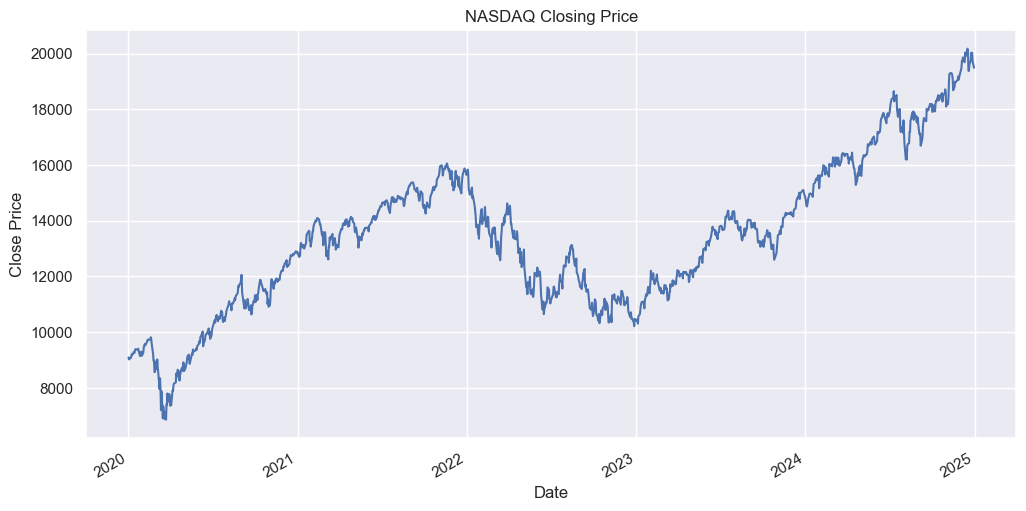

In [21]:
# plot time series line graph of target variable
data['Close'].plot(figsize=(12, 6), title="NASDAQ Closing Price")
plt.xlabel("Date")
plt.ylabel("Close Price");

Text(0, 0.5, 'Frequency')

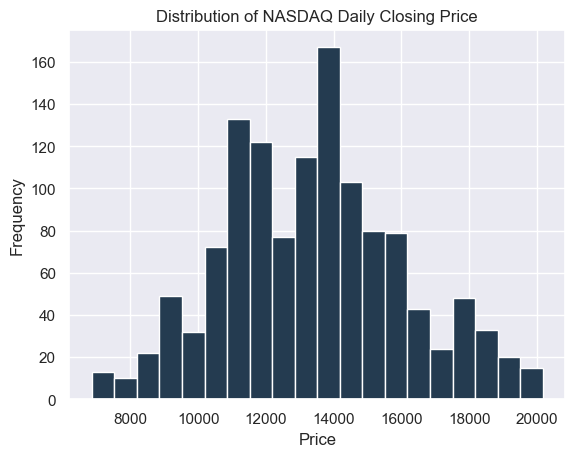

In [22]:
# plot histogram of target variable
data['Close'].hist(bins="auto", edgecolor='white', color='#243b50')
plt.title('Distribution of NASDAQ Daily Closing Price')
plt.xlabel('Price')
plt.ylabel('Frequency')

It looks like we may have a multimodal distribution for our target variable.

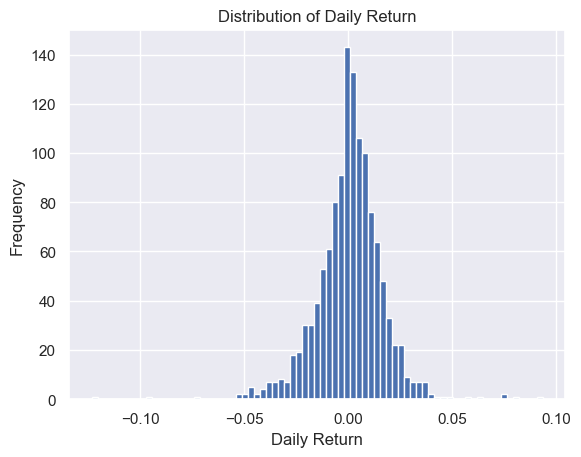

In [23]:
# plot histogram of 
data['Daily Return'] = data['Close'].pct_change()
data['Daily Return'].hist(bins=75, edgecolor='white')
plt.title('Distribution of Daily Return')
plt.xlabel('Daily Return')
plt.ylabel('Frequency');

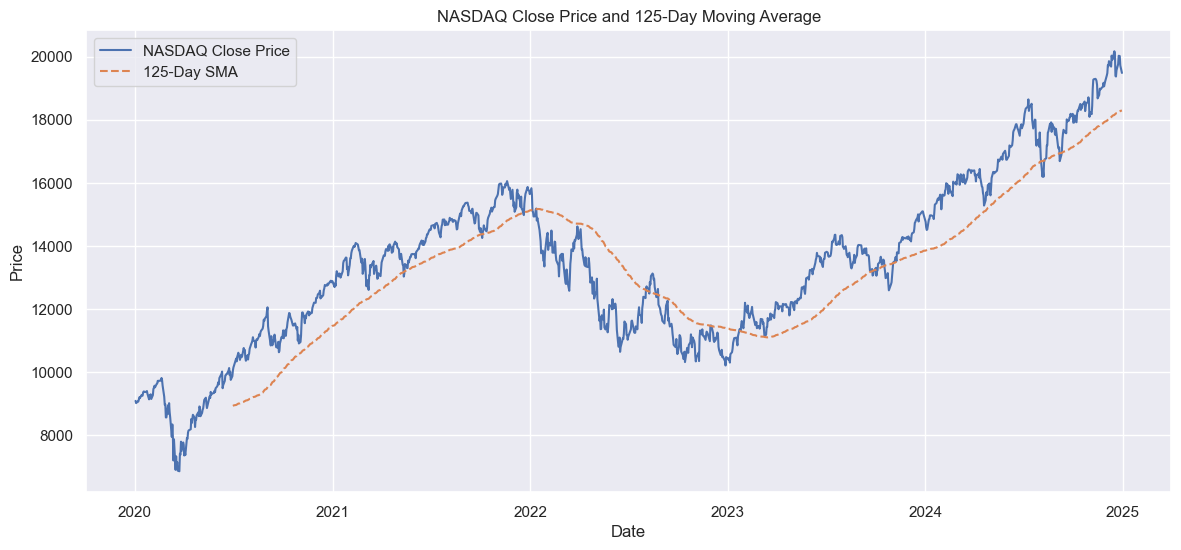

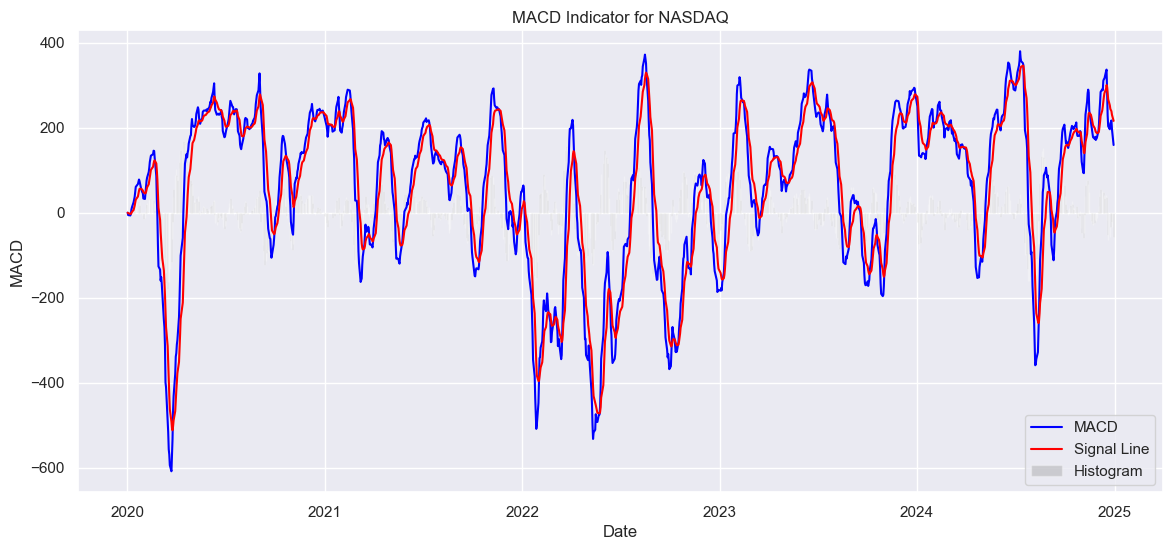

In [24]:
#explore MACD

# NASDAQ MACD Calucaltion

# 125-day Simple Moving Average
data['SMA_125'] = data['Close'].rolling(window=125).mean()

# MACD Calculation
short_ema = data['Close'].ewm(span=12, adjust=False).mean() 
long_ema = data['Close'].ewm(span=26, adjust=False).mean()   
macd = short_ema - long_ema                                  
signal = macd.ewm(span=9, adjust=False).mean()               
histogram = macd - signal                                    

# Add to DataFrame
data['MACD'] = macd
data['MACD_Signal'] = signal
data['MACD_Hist'] = histogram

# Plotting Close Price and SMA
plt.figure(figsize=(14,6))
plt.plot(data['Close'], label='NASDAQ Close Price')
plt.plot(data['SMA_125'], label='125-Day SMA', linestyle='--')
plt.title("NASDAQ Close Price and 125-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

# Optional: Plot MACD with Histogram
plt.figure(figsize=(14,6))
plt.plot(data['MACD'], label='MACD', color='blue')
plt.plot(data['MACD_Signal'], label='Signal Line', color='red')
plt.bar(data.index, data['MACD_Hist'], label='Histogram', color='gray', alpha=0.3)
plt.title("MACD Indicator for NASDAQ")
plt.xlabel("Date")
plt.ylabel("MACD")
plt.legend()
plt.grid(True)
plt.show()

## Split Data

Since we are working with time series data, there will be no data shuffling.

In [25]:
# Split data by year
train_data = data["2020-01-01":"2022-12-31"] # train data: 2020-2022
val_data = data["2023-01-01":"2023-12-31"] # val data: 2023
test_data = data["2024-01-01":"2024-12-31"] # test data: 2024

# Check shapes
print("Train:", train_data.shape)
print("Validate:", val_data.shape)
print("Test:", test_data.shape)

Train: (756, 23)
Validate: (250, 23)
Test: (251, 23)


In [26]:
train_data.head()

,Open,High,Low,Close,Volume,FEDFUNDS,DGS10,CPIAUCSL,PPIACO,M2SL,...,TLT_Close,TLT_Volume,TLT_Capital Gains,VIX_Close,MACD,MACD_Signal,MACD_Hist,Yield_Spread,Daily Return,SMA_125
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,9039.459961,9093.429688,9010.889648,9092.190430,2862700000,1.55,1.92,257.879,199.0,15167.3,...,119.346962,11034100,0.0,12.47,0.000000,0.000000,0.000000,0.37,NaN,NaN
2020-01-03,8976.429688,9065.759766,8976.429688,9020.769531,2586520000,1.55,1.88,257.879,199.0,15167.3,...,121.184967,12366000,0.0,14.02,-5.697394,-1.139479,-4.557915,0.33,-0.007855,NaN
2020-01-06,8943.500000,9072.410156,8943.500000,9071.469727,2810450000,1.55,1.80,257.879,199.0,15167.3,...,120.496819,11369800,0.0,13.85,-6.051776,-2.121938,-3.929838,0.25,0.005620,NaN
2020-01-07,9076.639648,9091.929688,9042.549805,9068.580078,2381740000,1.55,1.81,257.879,199.0,15167.3,...,119.904434,8381200,0.0,13.79,-6.490973,-2.995745,-3.495228,0.26,-0.000319,NaN
2020-01-08,9068.030273,9168.889648,9059.379883,9129.240234,2472620000,1.55,1.83,257.879,199.0,15167.3,...,119.111778,10621700,0.0,13.45,-1.922115,-2.781019,0.858904,0.28,0.006689,NaN


In [27]:
val_data.head()

,Open,High,Low,Close,Volume,FEDFUNDS,DGS10,CPIAUCSL,PPIACO,M2SL,...,TLT_Close,TLT_Volume,TLT_Capital Gains,VIX_Close,MACD,MACD_Signal,MACD_Hist,Yield_Spread,Daily Return,SMA_125
Date,,,,,,,,,,,,,,,,,,,,,
2023-01-03,10562.059570,10613.059570,10309.160156,10386.980469,4780650000,3.78,3.88,298.708,263.157,21424.6,...,93.219986,25313200,0.0,22.900000,-183.474039,-141.937018,-41.537021,0.10,-0.007596,11380.001625
2023-01-04,10467.820312,10515.219727,10337.639648,10458.759766,5085380000,3.78,3.79,298.708,263.157,21424.6,...,94.497108,21678200,0.0,22.010000,-177.249173,-148.999449,-28.249724,0.01,0.006911,11370.700906
2023-01-05,10390.309570,10393.219727,10295.250000,10305.240234,4764270000,3.78,3.69,298.708,263.157,21424.6,...,94.892159,14771100,0.0,22.459999,-182.598779,-155.719315,-26.879465,-0.09,-0.014679,11360.060352
2023-01-06,10363.959961,10604.139648,10265.040039,10569.290039,5199780000,3.78,3.71,298.708,263.157,21424.6,...,96.637871,27473700,0.0,21.129999,-163.645367,-157.304525,-6.340842,-0.07,0.025623,11353.633875
2023-01-09,10662.099609,10807.259766,10619.120117,10635.650391,5132190000,3.78,3.55,298.708,263.157,21424.6,...,97.152390,21472200,0.0,21.969999,-141.637220,-154.171064,12.533845,-0.23,0.006279,11348.601234


In [28]:
test_data.head()

,Open,High,Low,Close,Volume,FEDFUNDS,DGS10,CPIAUCSL,PPIACO,M2SL,...,TLT_Close,TLT_Volume,TLT_Capital Gains,VIX_Close,MACD,MACD_Signal,MACD_Hist,Yield_Spread,Daily Return,SMA_125
Date,,,,,,,,,,,,,,,,,,,,,
2024-01-02,14873.700195,14887.799805,14682.379883,14765.940430,5791170000,5.33,3.88,307.653,255.192,20687.3,...,93.464355,47797400,0.0,13.20,250.010919,272.763156,-22.752237,-1.45,-0.016348,13856.026328
2024-01-03,14641.469727,14694.580078,14577.440430,14592.209961,5449950000,5.33,3.95,308.087,252.856,20687.3,...,93.854141,58159500,0.0,14.04,208.672361,259.944997,-51.272636,-1.38,-0.011766,13863.331688
2024-01-04,14532.230469,14632.769531,14504.780273,14510.299805,5289220000,5.33,3.91,308.087,252.856,20687.3,...,92.428070,52604500,0.0,14.13,167.372426,241.430483,-74.058057,-1.42,-0.005613,13870.128328
2024-01-05,14500.110352,14625.190430,14477.570312,14524.070312,5232820000,5.33,3.99,308.087,252.856,20687.3,...,91.543907,45883000,0.0,13.35,134.206051,219.985596,-85.779546,-1.34,0.000949,13876.837047
2024-01-08,14564.469727,14846.900391,14560.200195,14843.769531,6337770000,5.33,4.05,308.087,252.856,20687.3,...,92.447090,39485800,0.0,13.08,132.194657,202.427408,-70.232752,-1.28,0.022012,13885.501602


# Post-Split EDA

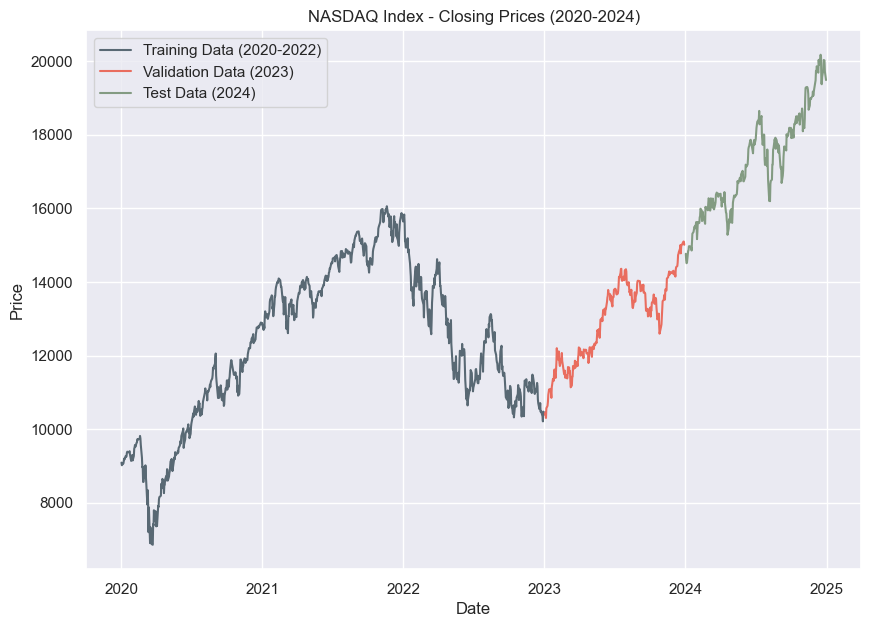

In [29]:
plt.figure(figsize=(10, 7))

plt.plot(train_data.index, train_data['Close'], label='Training Data (2020-2022)', color='#596974') # muted gray blue
plt.plot(val_data.index, val_data['Close'], label='Validation Data (2023)', color= "#e96d5f") # warm coral
plt.plot(test_data.index, test_data['Close'], label='Test Data (2024)', color= "#839b82")# muted green

plt.title('NASDAQ Index - Closing Prices (2020-2024)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

In [30]:
train_data.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'FEDFUNDS', 'DGS10',
       'CPIAUCSL', 'PPIACO', 'M2SL', 'TLT_Open', 'TLT_High', 'TLT_Low',
       'TLT_Close', 'TLT_Volume', 'TLT_Capital Gains', 'VIX_Close', 'MACD',
       'MACD_Signal', 'MACD_Hist', 'Yield_Spread', 'Daily Return', 'SMA_125'],
      dtype='object')

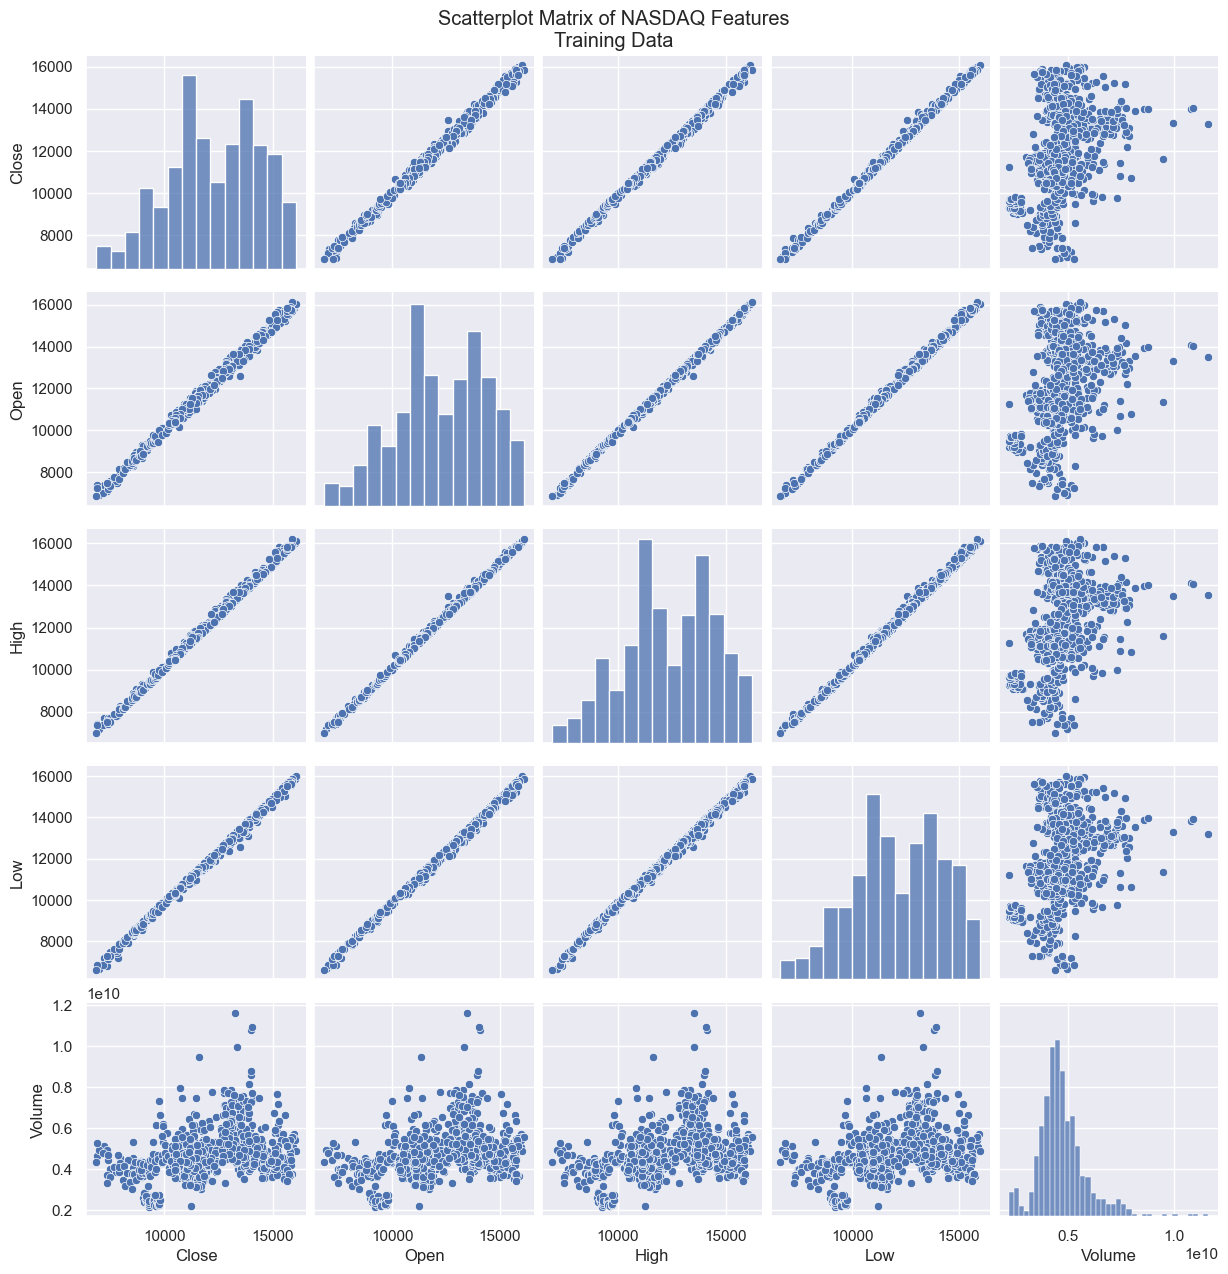

In [31]:
s = sns.pairplot(train_data[['Close','Open', 'High', 'Low', 'Volume']])
s.fig.suptitle('Scatterplot Matrix of NASDAQ Features\nTraining Data', y=1.02)
plt.show()

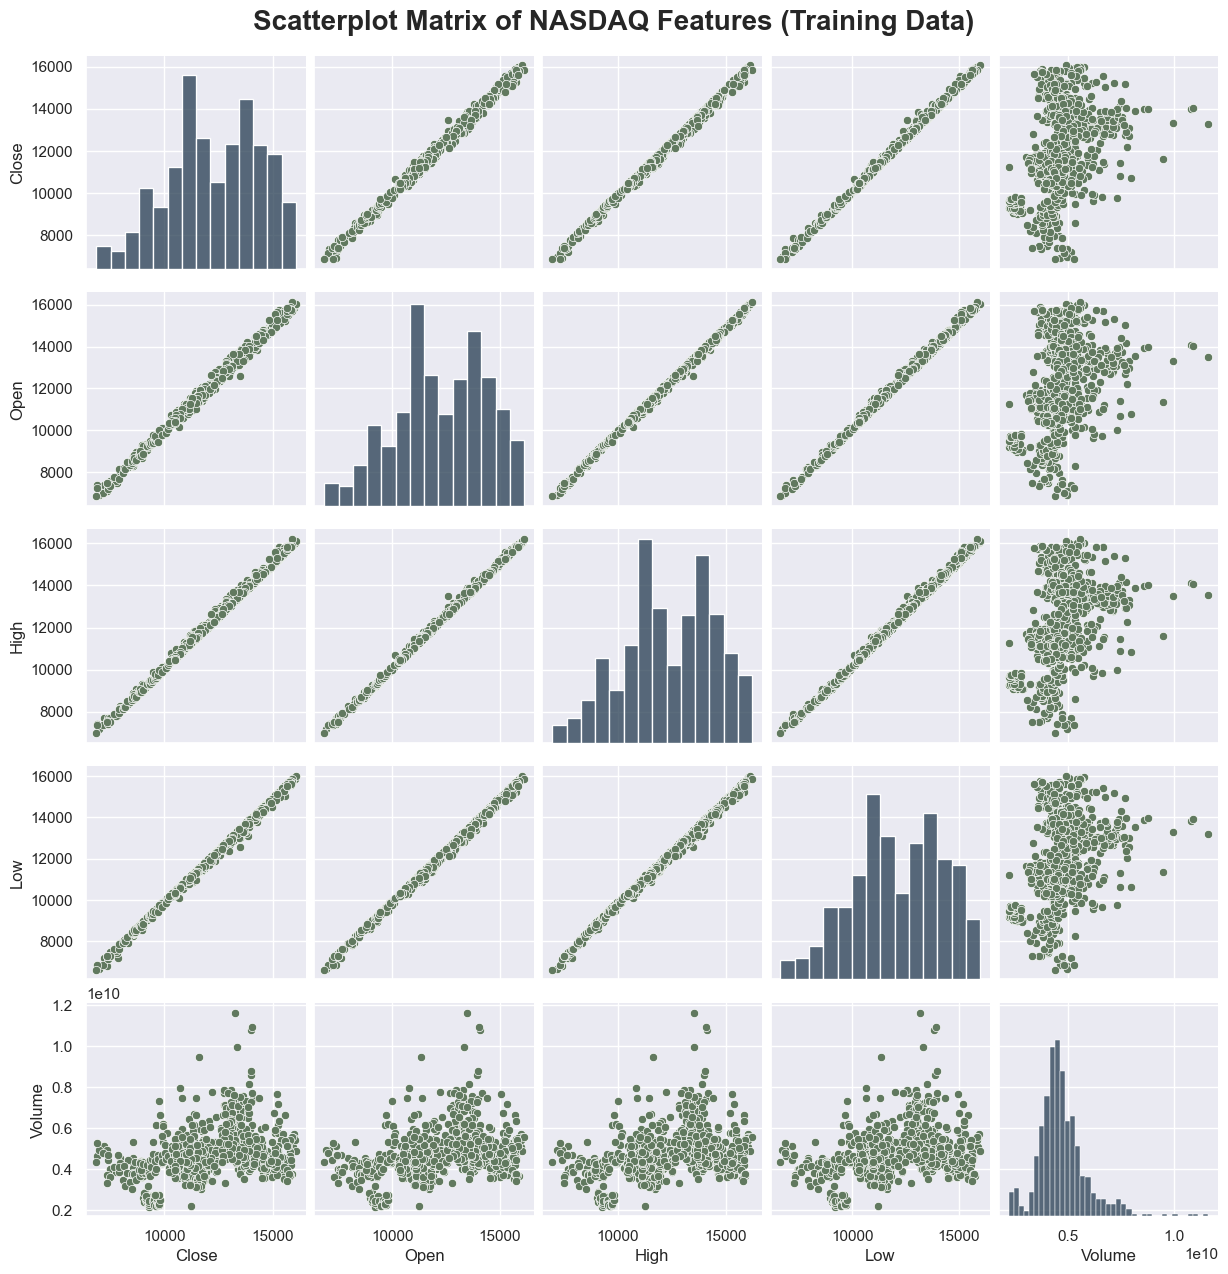

In [32]:
# creating similar plot for presentation
s = sns.pairplot(
    train_data[['Close','Open', 'High', 'Low', 'Volume']],
    plot_kws={'color': '#61795f'},
    diag_kws={'color': '#243b50'}   
)
s.fig.suptitle('Scatterplot Matrix of NASDAQ Features (Training Data)',
               y=1.02, fontsize=20, fontweight='bold')
plt.show()

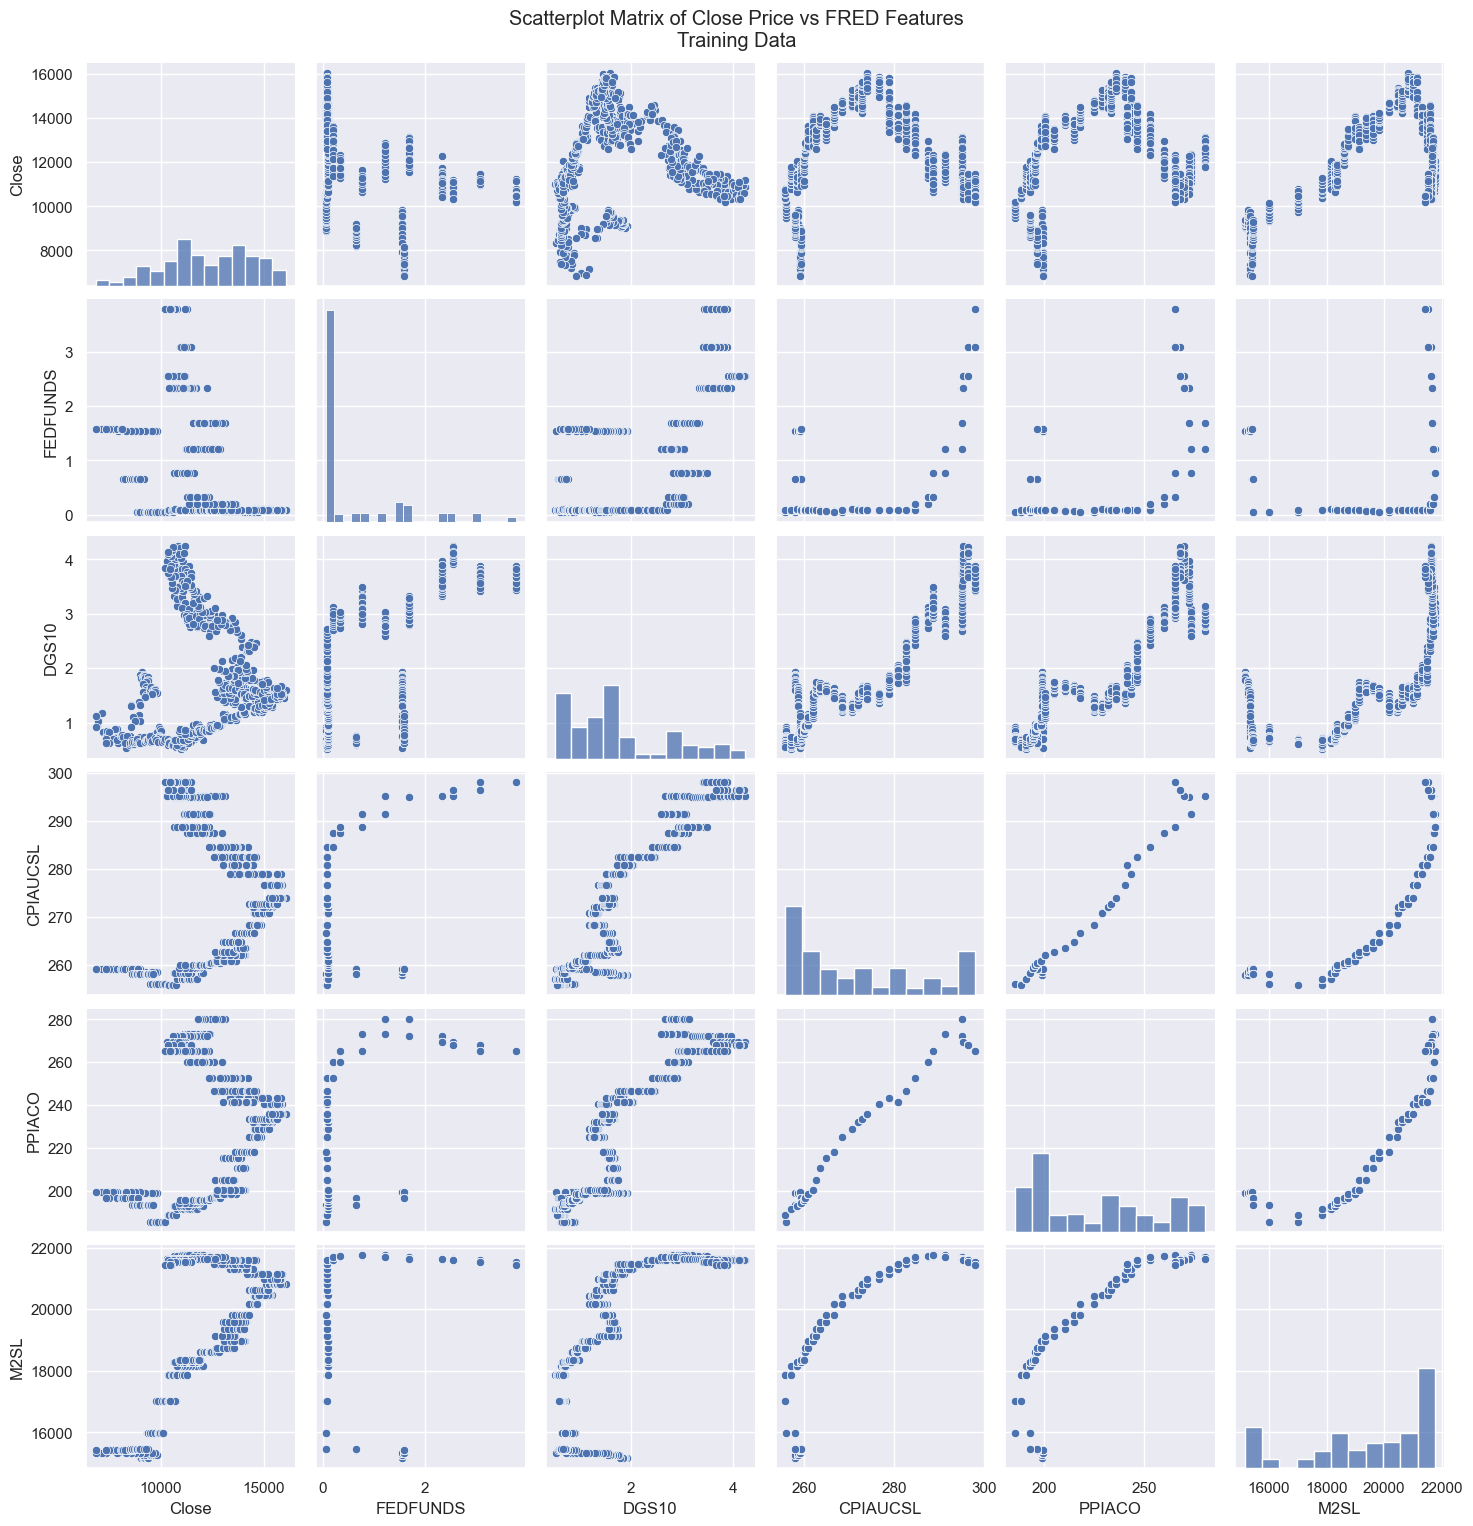

In [33]:
s = sns.pairplot(train_data[['Close','FEDFUNDS', 'DGS10','CPIAUCSL', 'PPIACO', 'M2SL']])
s.fig.suptitle('Scatterplot Matrix of Close Price vs FRED Features\nTraining Data', y=1.02)
plt.show()

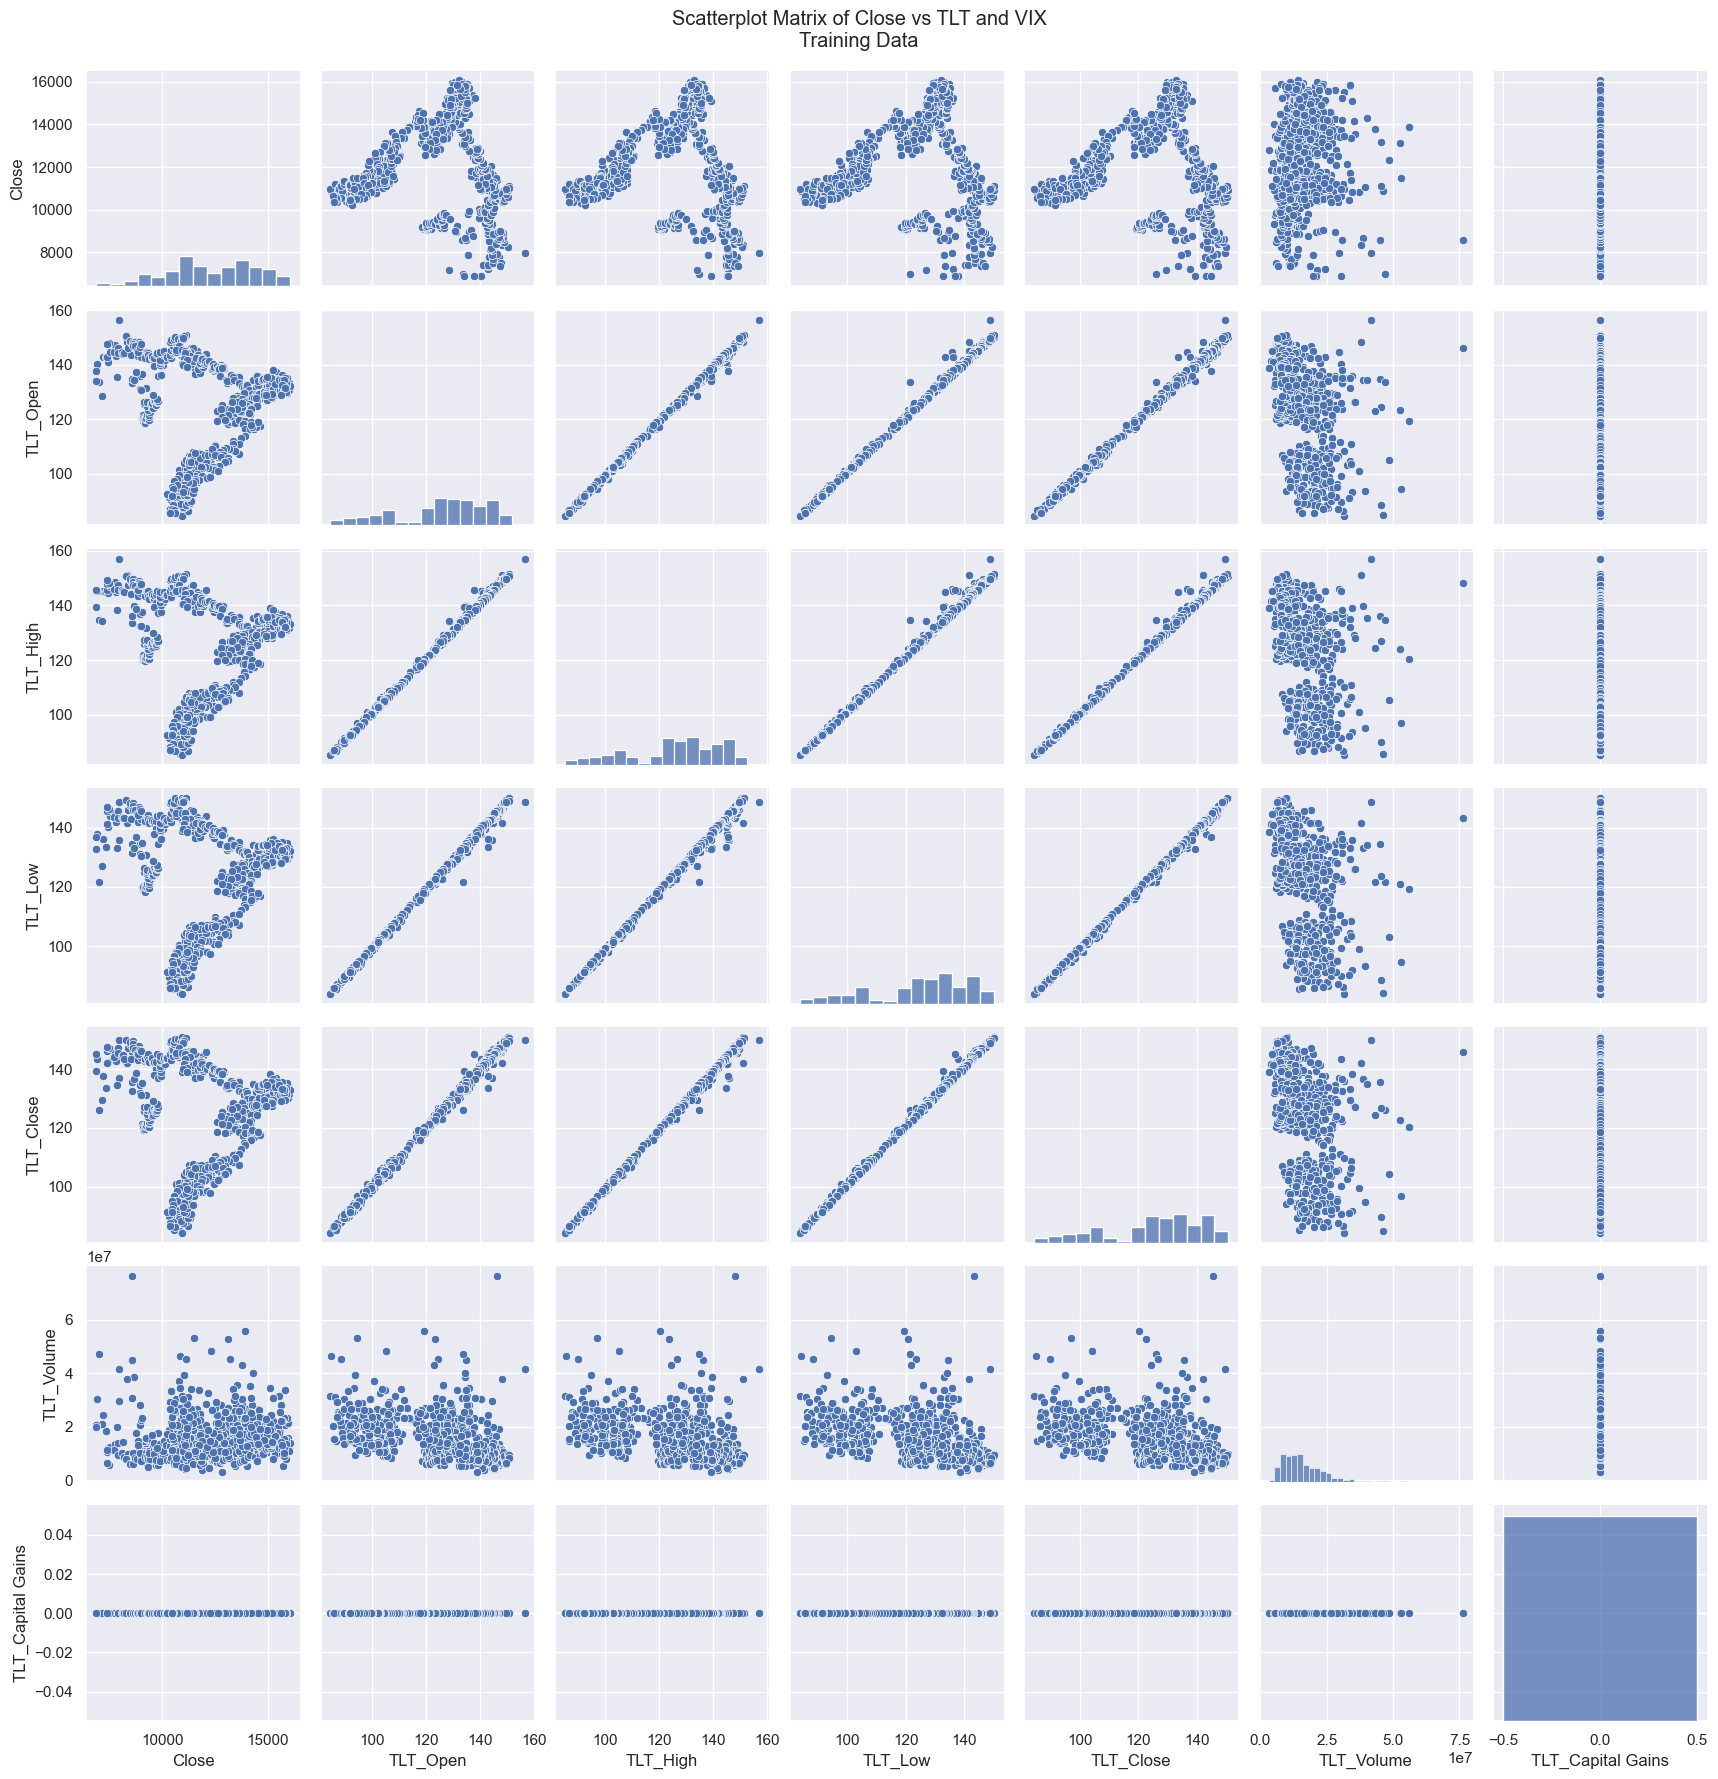

In [34]:
s = sns.pairplot(train_data[['Close','TLT_Open', 'TLT_High', 'TLT_Low',
       'TLT_Close', 'TLT_Volume', 'TLT_Capital Gains']])
s.fig.suptitle('Scatterplot Matrix of Close vs TLT and VIX\nTraining Data', y=1.02)
plt.show()

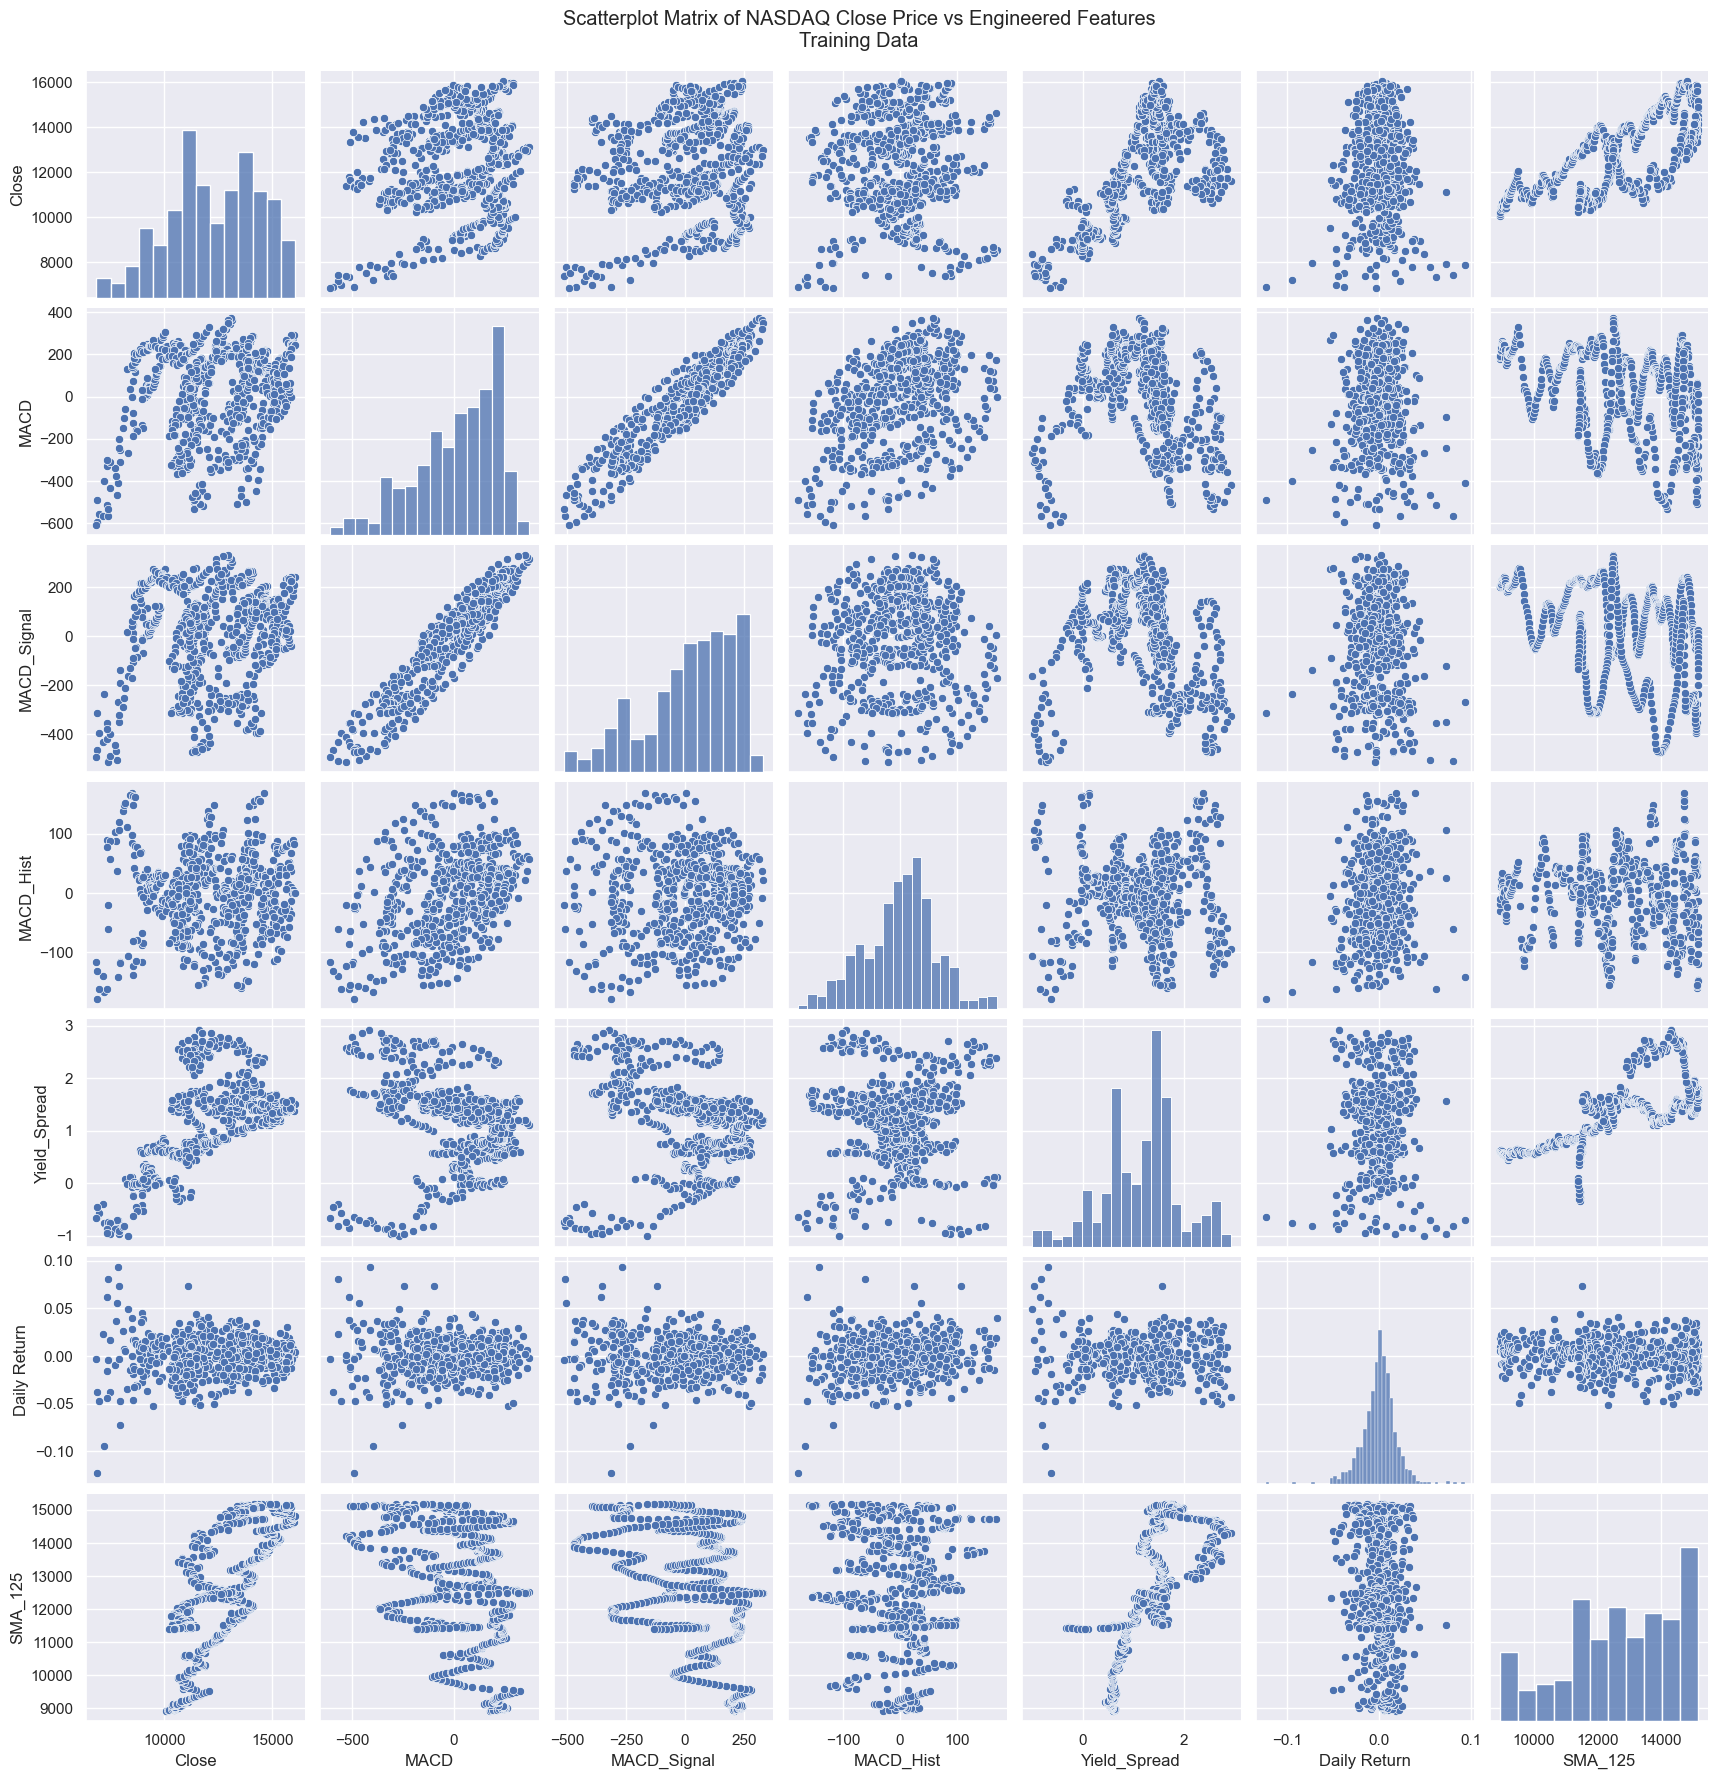

In [35]:
s = sns.pairplot(train_data[['Close','MACD', 'MACD_Signal', 'MACD_Hist', 'Yield_Spread', 'Daily Return', 'SMA_125']])
s.fig.suptitle('Scatterplot Matrix of NASDAQ Close Price vs Engineered Features\nTraining Data', y=1.02)
plt.show()

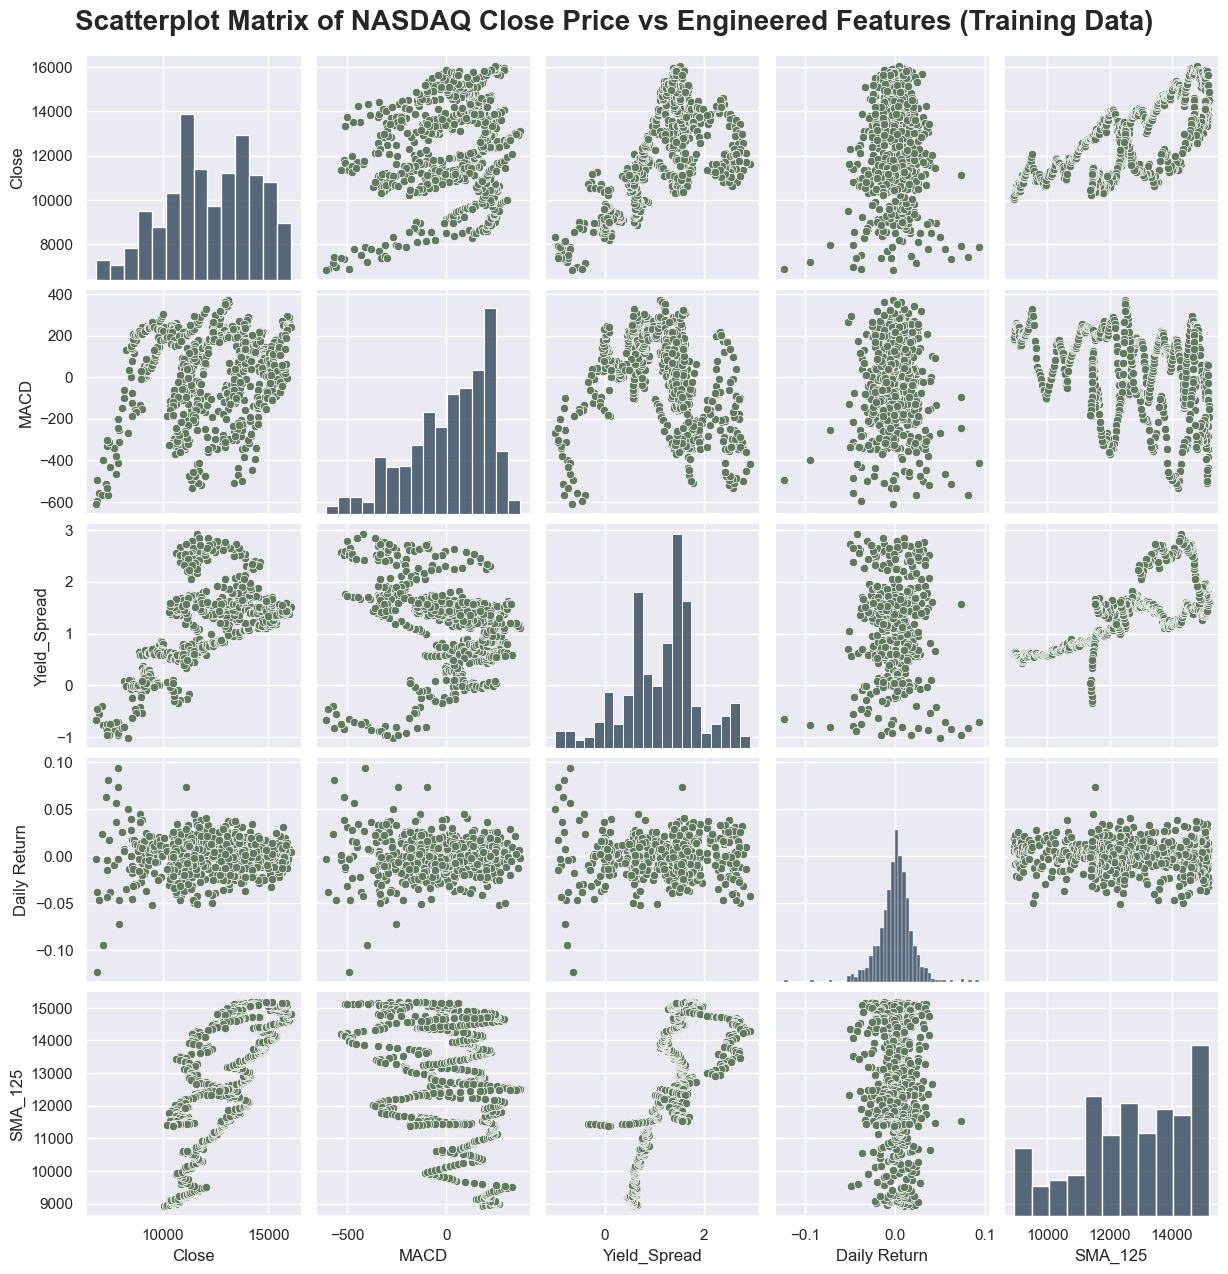

In [36]:
# creating similar plot for presentation
s = sns.pairplot(
    train_data[['Close','MACD', 'Yield_Spread', 'Daily Return', 'SMA_125']],
    plot_kws={'color': '#61795f'},
    diag_kws={'color': '#243b50'}   
)
s.fig.suptitle('Scatterplot Matrix of NASDAQ Close Price vs Engineered Features (Training Data)',
               y=1.02, fontsize=20, fontweight='bold')
plt.show()

<Axes: title={'center': 'Correlation Matrix Heatmap - Training Data'}>

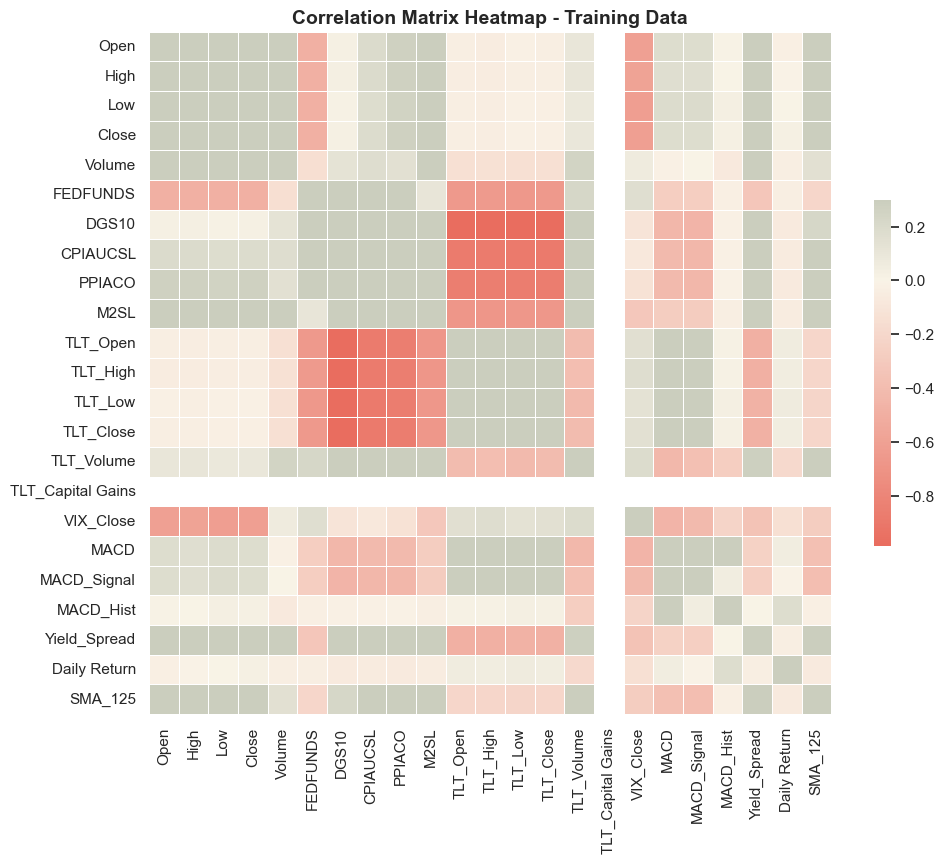

In [37]:
sns.set_theme(style="white")

# Compute the correlation matrix
corr = train_data.corr()

# Define custom color palette from slide deck hex codes
custom_hex_colors = [
    "#e96d5f",  # warm coral
    "#f9f3e7",  # soft cream
    "#61795f"   # muted green
]

# Create a custom diverging colormap
custom_cmap = LinearSegmentedColormap.from_list("custom_palette", custom_hex_colors)

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))

# Add title
plt.title("Correlation Matrix Heatmap - Training Data", fontsize=14, fontweight='bold')

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, cmap=custom_cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

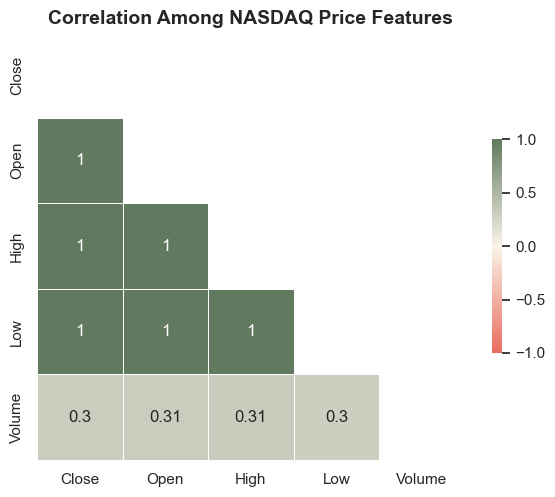

In [38]:
# === 1. NASDAQ Features Heatmap ===
nasdaq_cols = ['Close', 'Open', 'High', 'Low', 'Volume']
nasdaq_corr = corr.loc[nasdaq_cols, nasdaq_cols]

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(nasdaq_corr, dtype=bool))

plt.figure(figsize=(6, 5))
sns.heatmap(nasdaq_corr, mask=mask, cmap=custom_cmap, vmin=-1, vmax=1,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot=True)
plt.title("Correlation Among NASDAQ Price Features", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

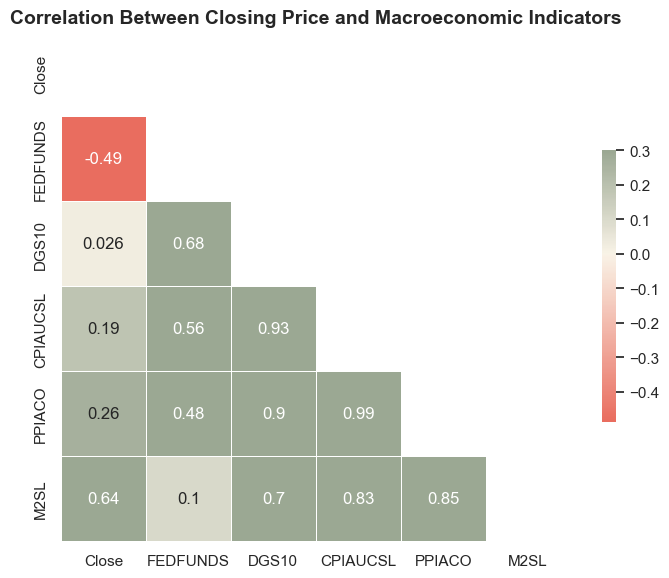

In [39]:
# === 2. Macroeconomic Indicators vs Close ===
macro_cols = ['Close', 'FEDFUNDS', 'DGS10', 'CPIAUCSL', 'PPIACO', 'M2SL']
macro_corr = corr.loc[macro_cols, macro_cols]

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(macro_corr, dtype=bool))

plt.figure(figsize=(7, 6))
sns.heatmap(macro_corr, mask=mask, cmap=custom_cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot=True)
plt.title("Correlation Between Closing Price and Macroeconomic Indicators", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

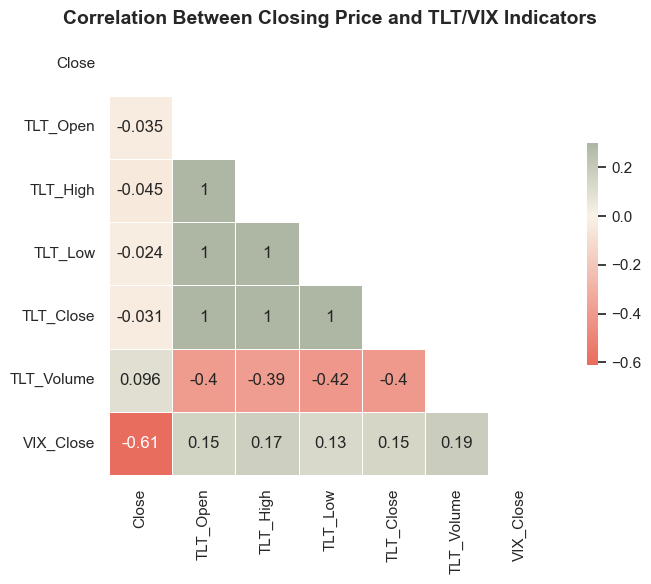

In [40]:
# === 3. TLT and VIX vs Close ===
tlt_vix_cols = ['Close', 'TLT_Open', 'TLT_High', 'TLT_Low',
                'TLT_Close', 'TLT_Volume', 'VIX_Close']
tlt_vix_corr = corr.loc[tlt_vix_cols, tlt_vix_cols]

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(tlt_vix_corr, dtype=bool))

plt.figure(figsize=(8, 6))
sns.heatmap(tlt_vix_corr, mask=mask, cmap=custom_cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot=True)
plt.title("Correlation Between Closing Price and TLT/VIX Indicators", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

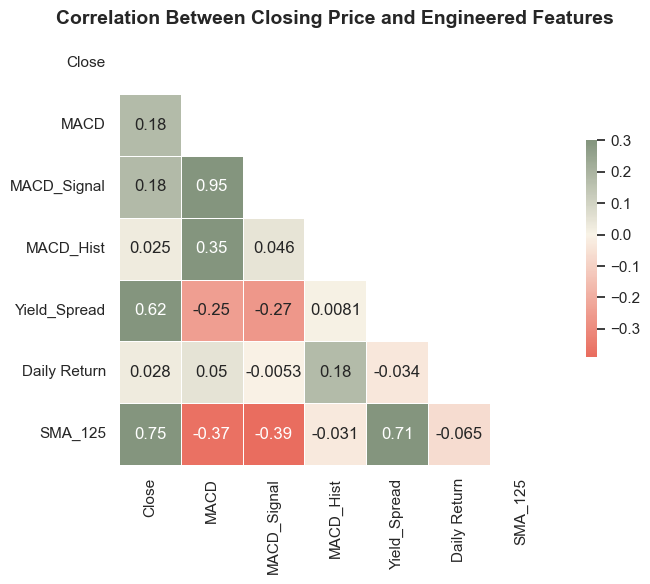

In [41]:
# === 4. Engineered Technical Features vs Close ===
engineered_cols = ['Close', 'MACD', 'MACD_Signal', 'MACD_Hist', 'Yield_Spread', 'Daily Return', 'SMA_125']
engineered_corr = corr.loc[engineered_cols, engineered_cols]

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(engineered_corr, dtype=bool))

plt.figure(figsize=(8, 6))
sns.heatmap(engineered_corr, mask=mask, cmap=custom_cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot=True)
plt.title("Correlation Between Closing Price and Engineered Features", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [42]:
data.head()

,Open,High,Low,Close,Volume,FEDFUNDS,DGS10,CPIAUCSL,PPIACO,M2SL,...,TLT_Close,TLT_Volume,TLT_Capital Gains,VIX_Close,MACD,MACD_Signal,MACD_Hist,Yield_Spread,Daily Return,SMA_125
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,9039.459961,9093.429688,9010.889648,9092.190430,2862700000,1.55,1.92,257.879,199.0,15167.3,...,119.346962,11034100,0.0,12.47,0.000000,0.000000,0.000000,0.37,NaN,NaN
2020-01-03,8976.429688,9065.759766,8976.429688,9020.769531,2586520000,1.55,1.88,257.879,199.0,15167.3,...,121.184967,12366000,0.0,14.02,-5.697394,-1.139479,-4.557915,0.33,-0.007855,NaN
2020-01-06,8943.500000,9072.410156,8943.500000,9071.469727,2810450000,1.55,1.80,257.879,199.0,15167.3,...,120.496819,11369800,0.0,13.85,-6.051776,-2.121938,-3.929838,0.25,0.005620,NaN
2020-01-07,9076.639648,9091.929688,9042.549805,9068.580078,2381740000,1.55,1.81,257.879,199.0,15167.3,...,119.904434,8381200,0.0,13.79,-6.490973,-2.995745,-3.495228,0.26,-0.000319,NaN
2020-01-08,9068.030273,9168.889648,9059.379883,9129.240234,2472620000,1.55,1.83,257.879,199.0,15167.3,...,119.111778,10621700,0.0,13.45,-1.922115,-2.781019,0.858904,0.28,0.006689,NaN
